In [12]:
import utils
import numpy as np
import pandas as pd
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [13]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural','reaction_time')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [14]:
# Preparation
pilot_analysis = False
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,807,808,809,810,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 11, 14]
    unique_sessions = [2, 3, 4]
recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

sub-005 did not complete session-02
sub-005 did not complete session-03
sub-005 did not complete session-04
sub-006 did not complete session-02
sub-006 did not complete session-03
sub-006 did not complete session-04
sub-007 did not complete session-04
sub-008 did not complete session-03
sub-008 did not complete session-04
sub-009 did not complete session-02
sub-009 did not complete session-03
sub-009 did not complete session-04
sub-010 did not complete session-02
sub-010 did not complete session-03
sub-010 did not complete session-04


In [15]:
if not recent_results:
    raise Exception('No files found')
else:
    print(recent_results)

['/Volumes/project/3025011.02/raw/sub-003/ses-mri01/beh/behavioural_output_sub-003_session-01_dummy_2025-02-06_10-42-51.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri02/beh/behavioural_output_sub-003_session-02_skyra_2025-02-13_12-00-57.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri03/beh/behavioural_output_sub-003_session-03_skyra_2025-02-18_15-30-50.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri04/beh/behavioural_output_sub-003_session-04_skyra_2025-02-21_16-11-25.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri01/beh/behavioural_output_sub-004_session-01_dummy_2025-02-19_14-33-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri02/beh/behavioural_output_sub-004_session-02_dummy_2025-02-20_11-40-53.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri03/beh/behavioural_output_sub-004_session-03_skyra_2025-02-25_15-34-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri04/beh/behavioural_output_sub-004_session-04_skyra_2025-03-03_17-11-46.csv',

In [16]:
### Remove invalid files
# Remove files that contain invalid data
invalid_data = pd.read_csv(f'{raw_output_path}../incomplete_data.csv', delimiter=';')
combinations = {
    f"sub-{row['subject-id']:03}_session-{row['session-number']:02}"
    for _, row in invalid_data[invalid_data['datatype'] == 'beh'].iterrows()
}
print(f'These participants will be excluded: {combinations}\n')

patterns = [re.compile(re.escape(combo)) for combo in combinations]
# Filter the list: remove any string that contains one of the combinations
recent_results = [
    item for item in recent_results
    if not any(pattern.search(item) for pattern in patterns)
]
print(recent_results)

These participants will be excluded: {'sub-003_session-03'}
['/Volumes/project/3025011.02/raw/sub-003/ses-mri01/beh/behavioural_output_sub-003_session-01_dummy_2025-02-06_10-42-51.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri02/beh/behavioural_output_sub-003_session-02_skyra_2025-02-13_12-00-57.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri04/beh/behavioural_output_sub-003_session-04_skyra_2025-02-21_16-11-25.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri01/beh/behavioural_output_sub-004_session-01_dummy_2025-02-19_14-33-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri02/beh/behavioural_output_sub-004_session-02_dummy_2025-02-20_11-40-53.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri03/beh/behavioural_output_sub-004_session-03_skyra_2025-02-25_15-34-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri04/beh/behavioural_output_sub-004_session-04_skyra_2025-03-03_17-11-46.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri01/beh/behaviour

In [17]:
combined_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          0        1.738835e+09      NaN                Late   
1          1        1.738835e+09       up                Even   
2          2        1.738835e+09       up                Even   
3          3        1.738835e+09       up                Even   
4          4        1.738835e+09     down                Even   
...      ...                 ...      ...                 ...   
10683    663        1.741691e+09       up                True   
10684    664        1.741691e+09       up               False   
10685    665        1.741691e+09       up               False   
10686    666        1.741691e+09     down                True   
10687    667        1.741691e+09       up                True   

      subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                     Late   1.738835e+09  1.211   1.738835e+09             2   
1                     True   1.738835e+09  0.428   1.7388

In [18]:
# List of subject_session combinations to update
match_list = ['sub-004_session-04']

# Create a new column that combines subject_id and session in the same format as the list.
combined_dataframe['sub_session'] = combined_dataframe['subject_id'] + '_' + combined_dataframe['session']

# Create a mask for rows that match any of the combinations in match_list.
mask = combined_dataframe['sub_session'].isin(match_list)

# For 'probability_condition', swap 80 with 20 and vice versa.
combined_dataframe.loc[mask, 'probability_condition'] = (
    combined_dataframe.loc[mask, 'probability_condition']
    .replace({80: 20, 20: 80})
)

# For 'response', swap 'up' with 'down' and vice versa.
combined_dataframe.loc[mask, 'response'] = (
    combined_dataframe.loc[mask, 'response']
    .replace({'up': 'down', 'down': 'up'})
)

# Optionally, drop the helper column
combined_dataframe.drop(columns='sub_session', inplace=True)

print(combined_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          0        1.738835e+09      NaN                Late   
1          1        1.738835e+09       up                Even   
2          2        1.738835e+09       up                Even   
3          3        1.738835e+09       up                Even   
4          4        1.738835e+09     down                Even   
...      ...                 ...      ...                 ...   
10683    663        1.741691e+09       up                True   
10684    664        1.741691e+09       up               False   
10685    665        1.741691e+09       up               False   
10686    666        1.741691e+09     down                True   
10687    667        1.741691e+09       up                True   

      subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                     Late   1.738835e+09  1.211   1.738835e+09             2   
1                     True   1.738835e+09  0.428   1.7388

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [19]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_dataframe['subject_id'].unique()
unique_sessions = combined_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

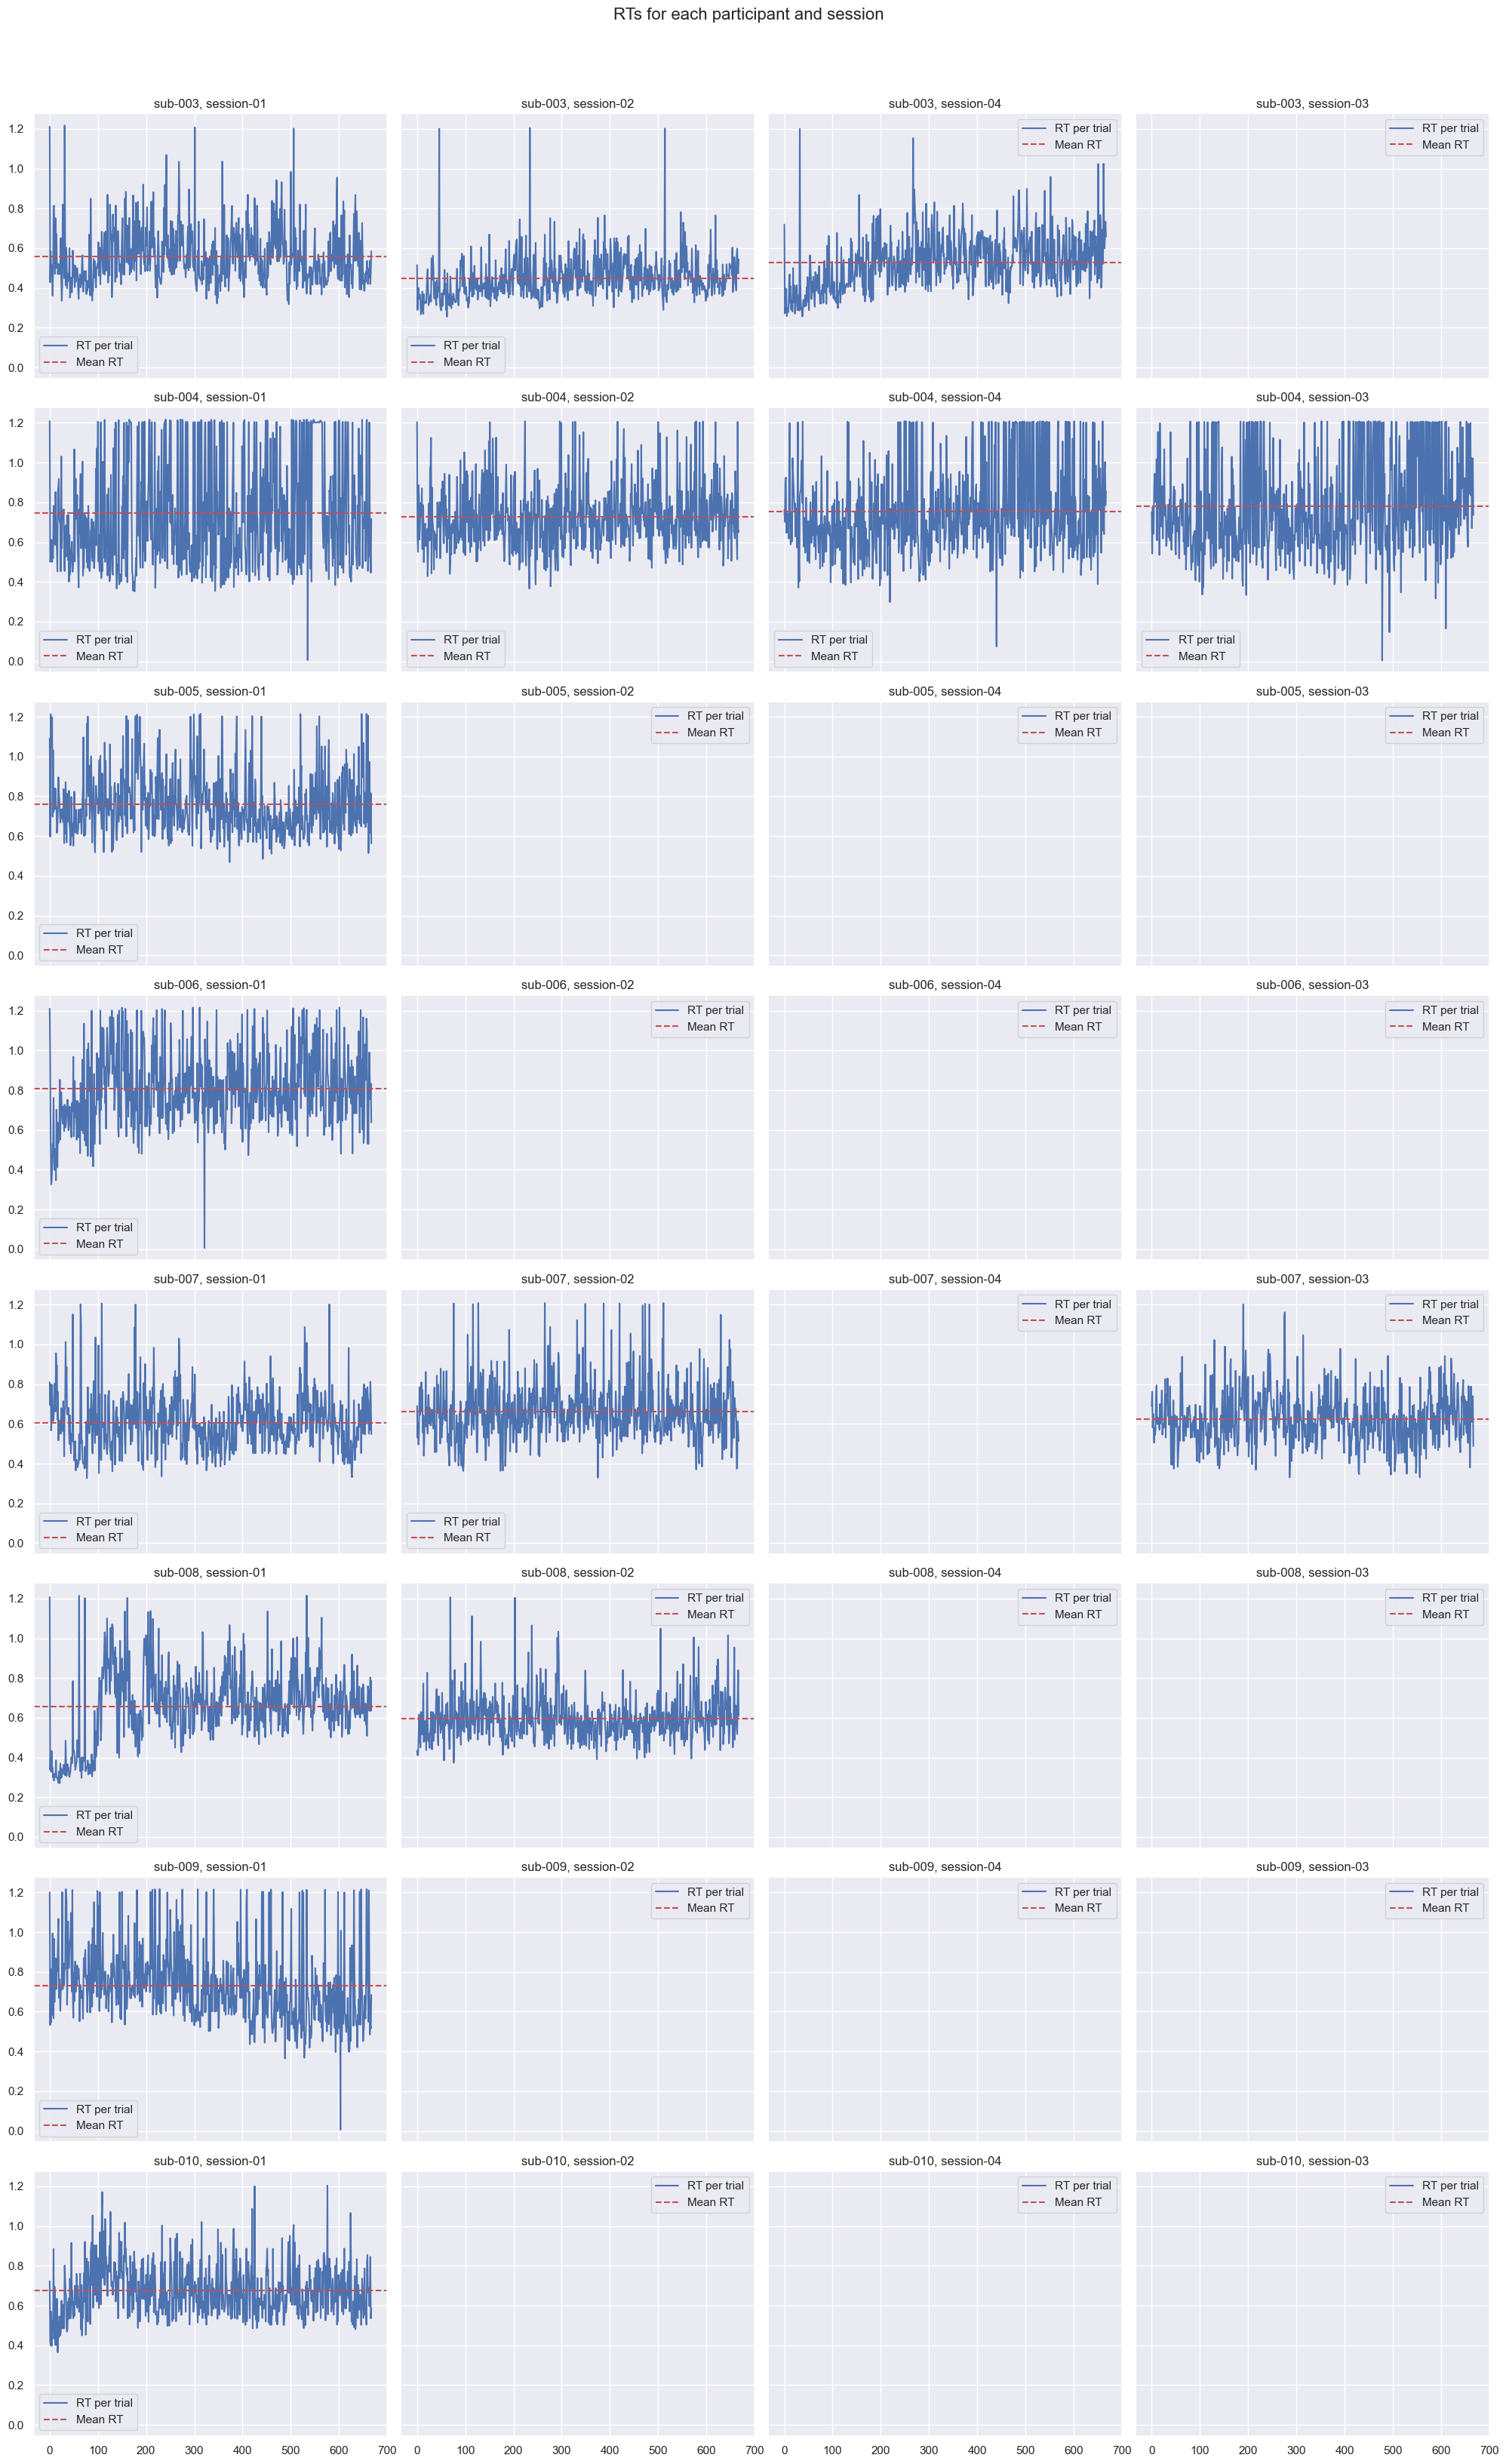

In [20]:
# Raw RT
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_dataframe[(combined_dataframe['session'] == session) & (combined_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT_s'].values, label=f'RT per trial')
        ax.axhline(subset['RT_s'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RT_for_each_participant_and_session.pdf'))
plt.show()

# Check if they're sleepy

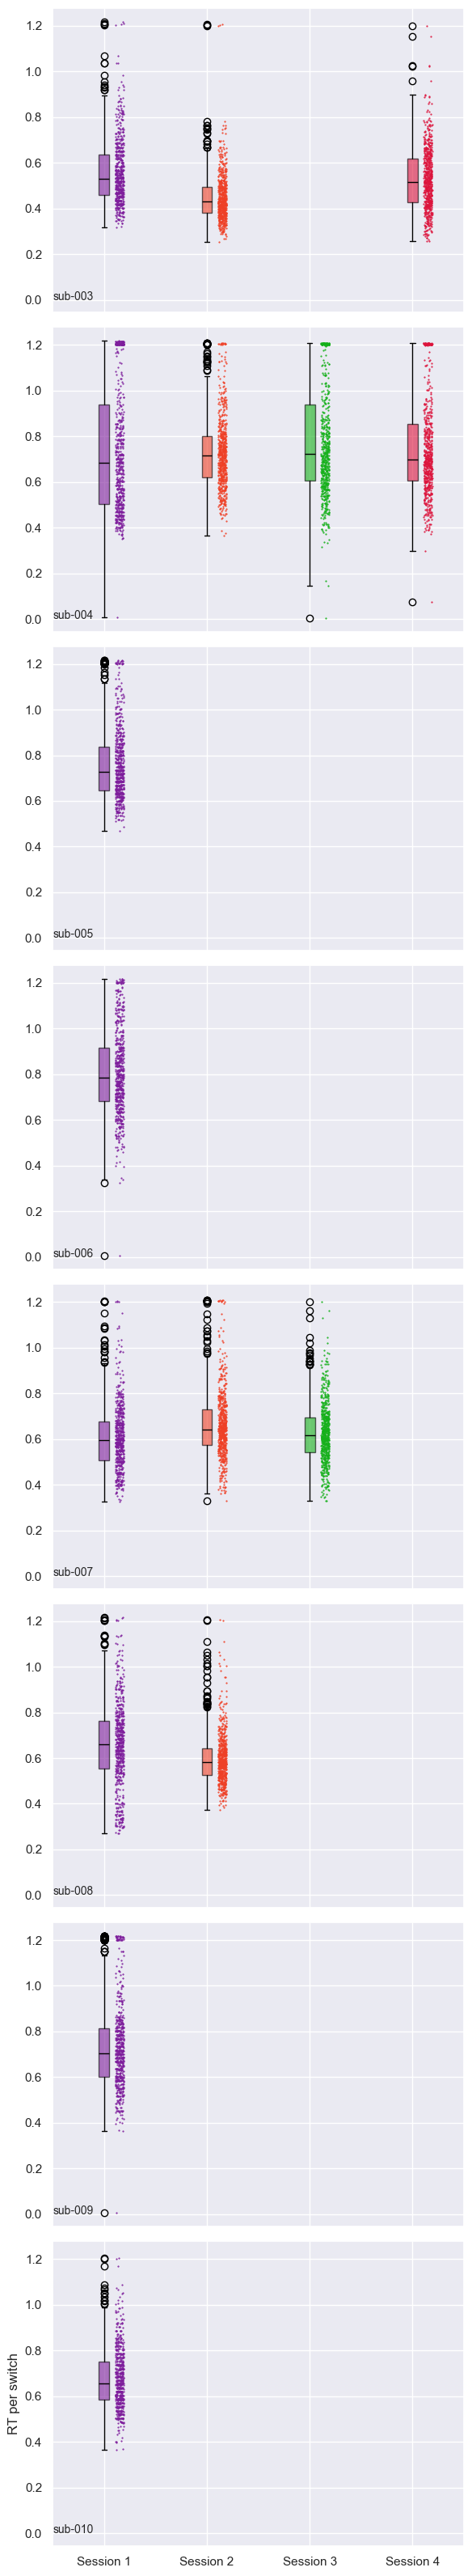

In [37]:
# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

fig, axes = plt.subplots(n_rows, 1, figsize=(6, n_rows*4), sharex=True, sharey=True)
if n_rows == 1:
    axes = np.array(axes).reshape(n_rows)

for i, subject_id in enumerate(unique_subject_ids):
    ax = axes[i]

    ## Filter the dataframe for the current session and subject_id
    dataframe_1 = combined_dataframe[(combined_dataframe['subject_id'] == subject_id) & (combined_dataframe['session'] == 'session-01')]
    list_1 = dataframe_1['RT_s'].dropna().tolist()
    dataframe_2 = combined_dataframe[(combined_dataframe['subject_id'] == subject_id) & (combined_dataframe['session'] == 'session-02')]
    list_2 = dataframe_2['RT_s'].dropna().tolist()
    dataframe_3 = combined_dataframe[(combined_dataframe['subject_id'] == subject_id) & (combined_dataframe['session'] == 'session-03')]
    list_3 = dataframe_3['RT_s'].dropna().tolist()
    dataframe_4 = combined_dataframe[(combined_dataframe['subject_id'] == subject_id) & (combined_dataframe['session'] == 'session-04')]
    list_4 = dataframe_4['RT_s'].dropna().tolist()
    valence_list = [list_1, list_2, list_3, list_4]

    # Boxplot data
    bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                    capprops=dict(color=c),
                    whiskerprops=dict(color=c),
                    flierprops=dict(color=c, markeredgecolor=c),
                    medianprops=dict(color=c))
    # Change to the desired color and add transparency
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for median in bp['medians']:
        median.set_color('black')

#    # Violinplot data (specify points as length data)
#    vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
#                       showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
#    # Change to the desired color
#    for idx, b in enumerate(vp['bodies']): # Slices it in half
#        # Change to the desired color
#        b.set_color(plot_colors[idx])

    # Scatterplot data
    for idx, features in enumerate(valence_list):
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + .75)
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
        x = out + 0.4
        ax.scatter(x, features, s=.3, c=plot_colors[idx])

    ax.text(0.5, 0, f'{subject_id}', fontsize=10)

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Session 1','Session 2','Session 3','Session 4'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_sleep_check'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

# Check congruency, valence and volatility

In [73]:
# Remove non-response trials
print(combined_dataframe)
combined_dataframe = combined_dataframe[combined_dataframe['response'].notna()]
print(combined_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.741019e+09     down                Even   
1        1        1.741019e+09       up                Even   
2        2        1.741019e+09     down                Even   
3        3        1.741019e+09       up                Even   
4        4        1.741019e+09     down                Even   
..     ...                 ...      ...                 ...   
663    663        1.741021e+09       up                True   
664    664        1.741021e+09       up                True   
665    665        1.741021e+09       up                True   
666    666        1.741021e+09       up                True   
667    667        1.741021e+09       up               False   

    subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   True   1.741019e+09  0.762   1.741019e+09             2   
1                  False   1.741019e+09  0.702   1.741019e+09             1   
2     

In [74]:
# Check a block's congruency
combined_dataframe['congruency'] = combined_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
combined_dataframe['valence'] = combined_dataframe.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
combined_dataframe = combined_dataframe[combined_dataframe['probability_condition'] != 50]
dataframe_with_volatility = combined_dataframe.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility)

dataframe_without_volatility = combined_dataframe

     trial  emotional_cue_time response objectively_correct  \
0        7        1.741019e+09     down               False   
1        8        1.741019e+09     down               False   
2       14        1.741019e+09     down               False   
3       16        1.741019e+09       up                True   
4       17        1.741019e+09       up                True   
..     ...                 ...      ...                 ...   
575    656        1.741021e+09       up               False   
576    659        1.741021e+09     down                True   
577    661        1.741021e+09       up               False   
578    662        1.741021e+09     down                True   
579    667        1.741021e+09       up               False   

    subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                  False   1.741019e+09  0.648   1.741019e+09             1   
1                  False   1.741019e+09  0.669   1.741019e+09             1   
2     

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5830/2388503677.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = combined_dataframe.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


In [75]:
print(dataframe_without_volatility[['trial','stimuli_type','probability_condition']])
print(dataframe_with_volatility[['trial','stimuli_type','probability_condition']])

     trial  stimuli_type  probability_condition
7        7             1                     80
8        8             1                     80
10      10             2                     20
11      11             2                     20
12      12             2                     20
..     ...           ...                    ...
663    663             1                     80
664    664             1                     80
665    665             1                     80
666    666             1                     80
667    667             2                     20

[580 rows x 3 columns]
     trial  stimuli_type  probability_condition
0        7             1                     80
1        8             1                     80
2       14             1                     80
3       16             1                     80
4       17             1                     80
..     ...           ...                    ...
575    656             2                     20
576    659      

# Plot average RT for different groups
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility
- Valence/Congruency
- Valence/Congruency/Volatility

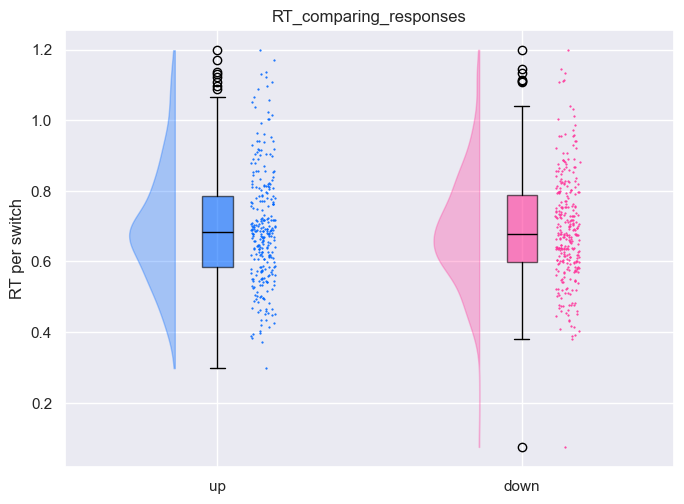

In [76]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['response'] == 'up']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['response'] == 'down']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['up', 'down'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_responses'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

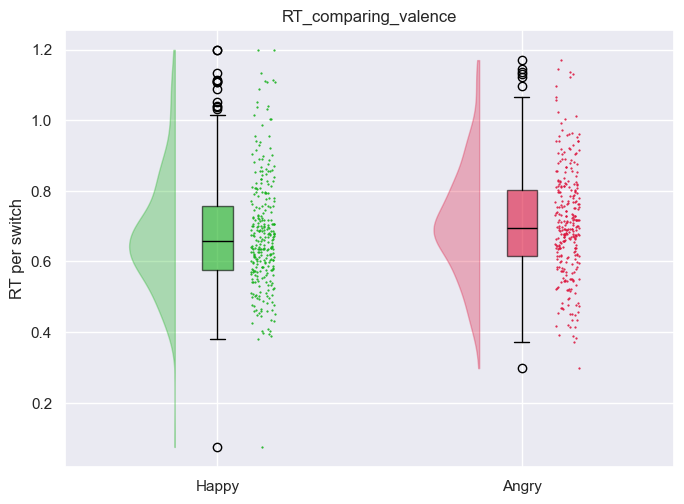

In [77]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['valence'] == 'happy']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['valence'] == 'angry']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Happy', 'Angry'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

OSError: [Errno 28] No space left on device

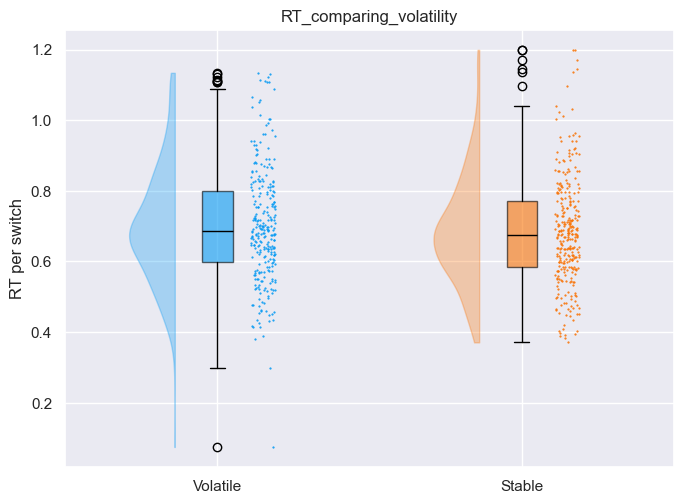

In [78]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['volatility'] == 'volatile']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['volatility'] == 'stable']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#069AF3', '#F97306']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Volatile', 'Stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

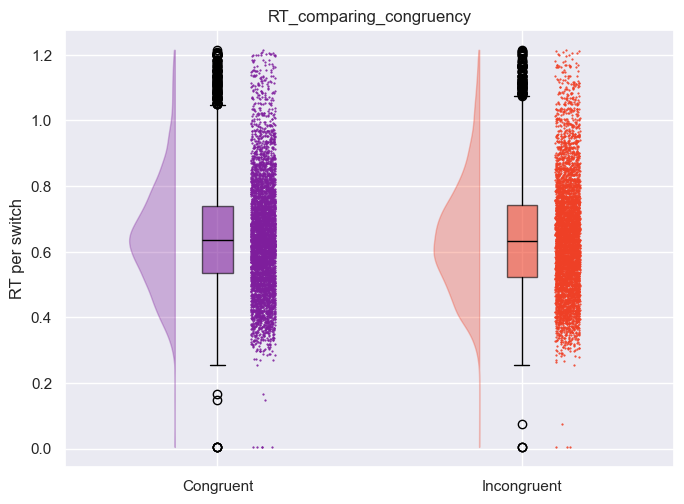

In [15]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['congruency'] == 'congruent']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['congruency'] == 'incongruent']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Congruent', 'Incongruent'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

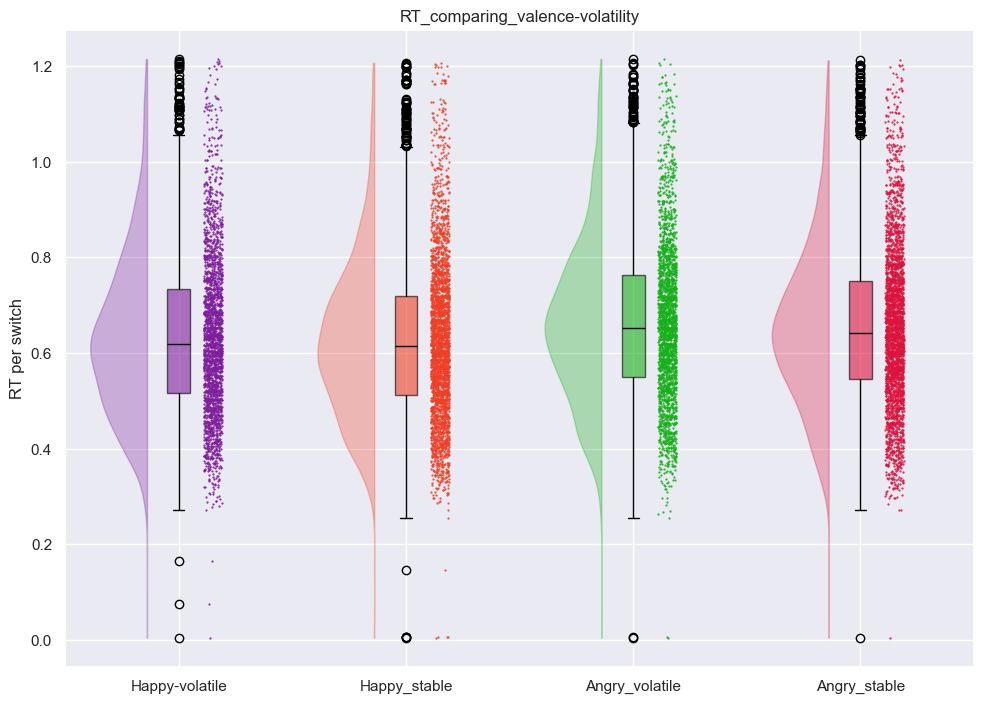

In [16]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_s'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_s'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_s'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['volatility'] == 'stable')]
list_4 = dataframe_4['RT_s'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Happy-volatile', 'Happy_stable', 'Angry_volatile', 'Angry_stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

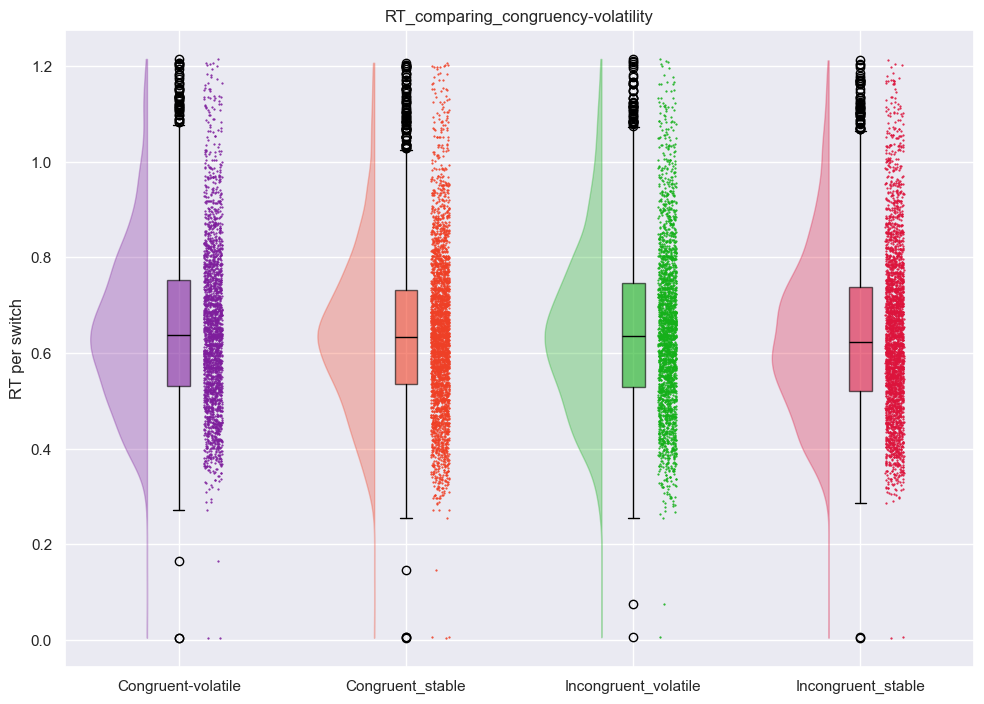

In [17]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_s'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_s'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_s'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_4 = dataframe_4['RT_s'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Congruent-volatile', 'Congruent_stable', 'Incongruent_volatile', 'Incongruent_stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

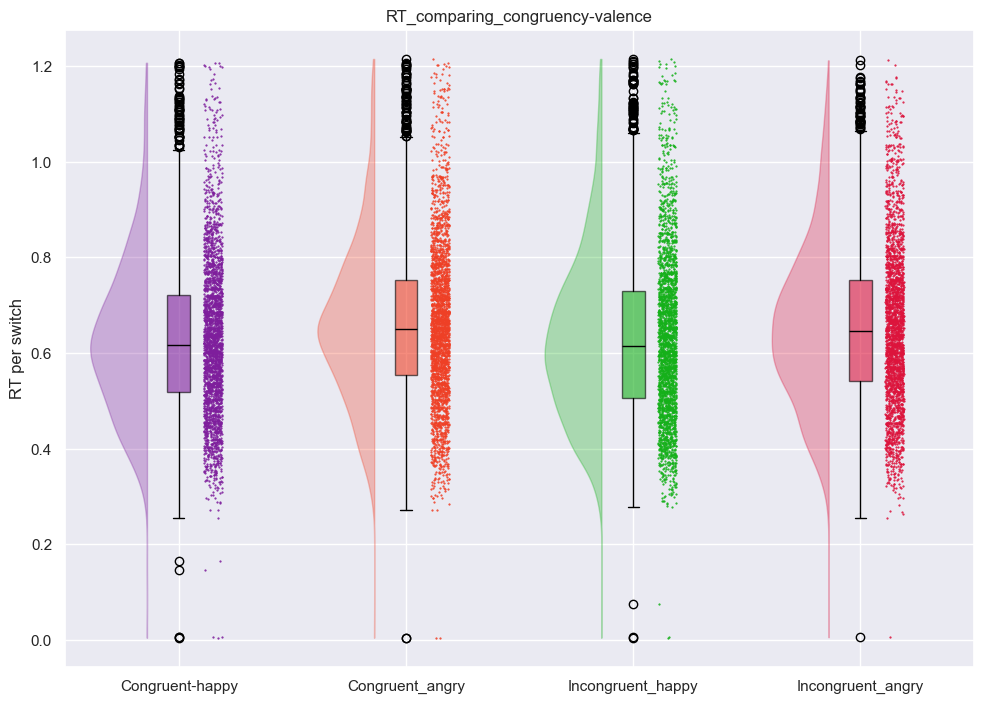

In [18]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['valence'] == 'happy')]
list_1 = dataframe_1['RT_s'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['valence'] == 'angry')]
list_2 = dataframe_2['RT_s'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['valence'] == 'happy')]
list_3 = dataframe_3['RT_s'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['valence'] == 'angry')]
list_4 = dataframe_4['RT_s'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Congruent-happy', 'Congruent_angry', 'Incongruent_happy', 'Incongruent_angry'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency-valence'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

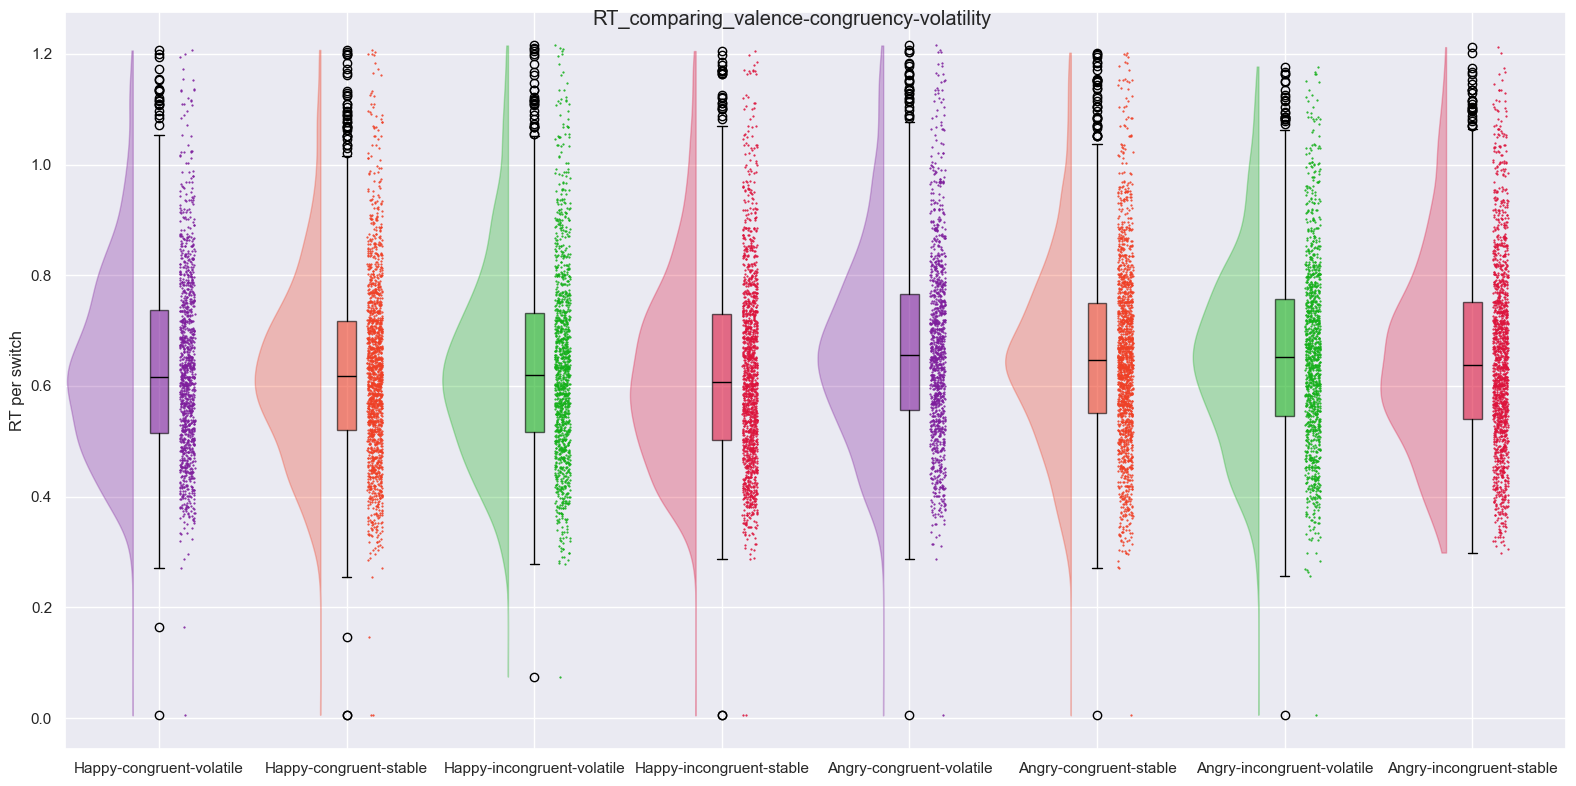

In [19]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_s'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_s'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_s'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_4 = dataframe_4['RT_s'].dropna().tolist()
dataframe_5 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_5 = dataframe_5['RT_s'].dropna().tolist()
dataframe_6 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_6 = dataframe_6['RT_s'].dropna().tolist()
dataframe_7 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_7 = dataframe_7['RT_s'].dropna().tolist()
dataframe_8 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_8 = dataframe_8['RT_s'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4, list_5, list_6, list_7, list_8]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C', '#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86, 4.86, 5.86, 6.86, 7.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,9,1), ['Happy-congruent-volatile', 'Happy-congruent-stable', 'Happy-incongruent-volatile', 'Happy-incongruent-stable', 'Angry-congruent-volatile', 'Angry-congruent-stable', 'Angry-incongruent-volatile', 'Angry-incongruent-stable', ])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-congruency-volatility'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()